In [ ]:
!pip install tensorflow scikit-learn matplotlib pandas

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, Input
from tensorflow.keras.layers import MultiHeadAttention, LayerNormalization
from tensorflow.keras.layers import Dropout, GlobalAveragePooling1D


In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"
df = pd.read_csv(url)

data = df['Passengers'].values.astype(float)
data = data.reshape(-1,1)

print("Data shape:", data.shape)
df.head()


Data shape: (144, 1)


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [ ]:
SEQ_LEN = 10

def make_seq(data, seq_len=SEQ_LEN):
    X, y = [], []
    for i in range(len(data)-seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

X, y = make_seq(data)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (134, 10, 1)
y shape: (134, 1)


In [ ]:
scalerX = MinMaxScaler()
X = scalerX.fit_transform(X.reshape(-1,1)).reshape(X.shape)

scalerY = MinMaxScaler()
y = scalerY.fit_transform(y)


In [ ]:
gru_model = Sequential([
    GRU(64, input_shape=(X.shape[1], X.shape[2])),
    Dense(1)
])

gru_model.compile(
    optimizer='adam',
    loss='mse'
)

gru_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        12,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,929 (50.50 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gru_model.fit(X, y, epochs=20, batch_size=16)
gru_pred = gru_model.predict(X)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - loss: 0.0748
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0180
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0142
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0125
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0095
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0082
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0079
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0084
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0078
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0079
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0077
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0083
Epoch 13/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0067
Epoch 14/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0072
Epoch 15/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0071
Epoch 16/20
9/9 ━━━━━━━━━━━━━━━━━━

In [ ]:
def transformer_model():

    inp = Input(shape=(X.shape[1], X.shape[2]))

    attn = MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(inp, inp)

    x = LayerNormalization()(attn + inp)
    x = GlobalAveragePooling1D()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.2)(x)

    out = Dense(1)(x)

    model = Model(inp, out)

    model.compile(
        optimizer='adam',
        loss='mse'
    )

    return model

trans_model = transformer_model()
trans_model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 10, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 10, 1)     │        449 │ input_layer_1[0]… │
│ (MultiHeadAttentio… │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 10, 1)     │          0 │ multi_head_atten… │
│                     │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 10, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1)         │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │        128 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 644 (2.52 KB)

 Trainable params: 644 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
trans_model.fit(X, y, epochs=20, batch_size=16)
trans_pred = trans_model.predict(X)


Epoch 1/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1925
Epoch 2/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1855
Epoch 3/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1822
Epoch 4/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.1659
Epoch 5/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1549  
Epoch 6/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1482 
Epoch 7/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1359 
Epoch 8/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1422 
Epoch 9/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1401 
Epoch 10/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1439 
Epoch 11/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1197 
Epoch 12/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1129 
Epoch 13/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1141 
Epoch 14/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1109 
Epoch 15/20
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1022 
Epoch 16/20
9/9 ━━━━━━━━━━━━━━━━━

In [ ]:
gru_loss = gru_model.evaluate(X,y)
trans_loss = trans_model.evaluate(X,y)

print("GRU Loss:", gru_loss)
print("Transformer Loss:", trans_loss)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0042 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0519 
GRU Loss: 0.006147720851004124
Transformer Loss: 0.09203524887561798


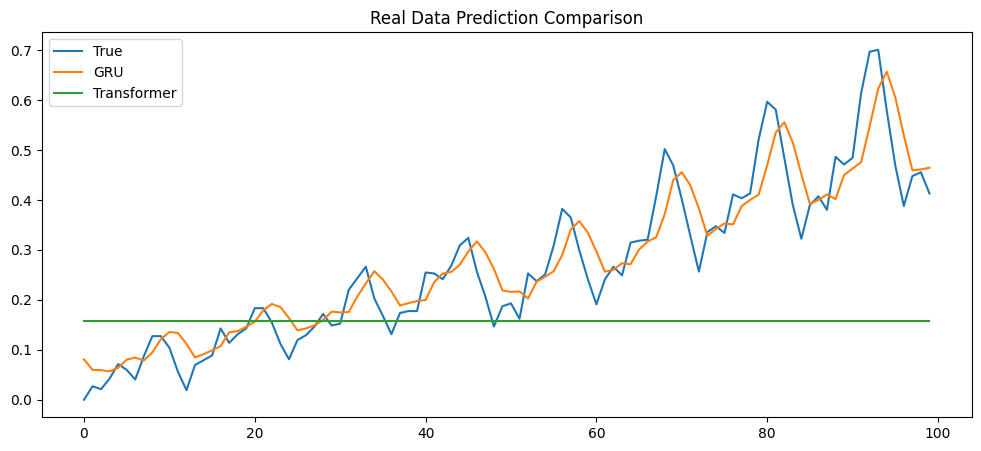

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y[:100], label="True")
plt.plot(gru_pred[:100], label="GRU")
plt.plot(trans_pred[:100], label="Transformer")

plt.legend()
plt.title("Real Data Prediction Comparison")
plt.show()


In [ ]:
from sklearn.model_selection import train_test_split

# Define threshold (simple rule)
threshold = np.mean(y)

# Create binary labels
handover_labels = (y < threshold).astype(int)

print("Sample labels:", handover_labels[:10])


Sample labels: [[1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]
 [1]]


In [ ]:
features = np.hstack([
    gru_pred,
    trans_pred
])

X_train, X_test, y_train, y_test = train_test_split(
    features,
    handover_labels,
    test_size=0.2,
    random_state=42
)


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))


Accuracy: 0.9259259259259259
              precision    recall  f1-score   support

           0       0.80      1.00      0.89         8
           1       1.00      0.89      0.94        19

    accuracy                           0.93        27
   macro avg       0.90      0.95      0.92        27
weighted avg       0.94      0.93      0.93        27



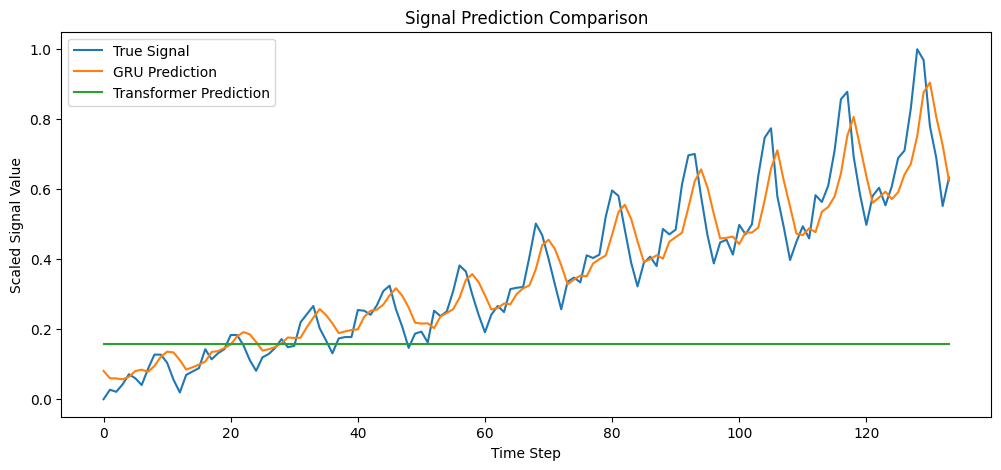

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y[:150], label="True Signal")
plt.plot(gru_pred[:150], label="GRU Prediction")
plt.plot(trans_pred[:150], label="Transformer Prediction")

plt.legend()
plt.title("Signal Prediction Comparison")
plt.xlabel("Time Step")
plt.ylabel("Scaled Signal Value")
plt.show()


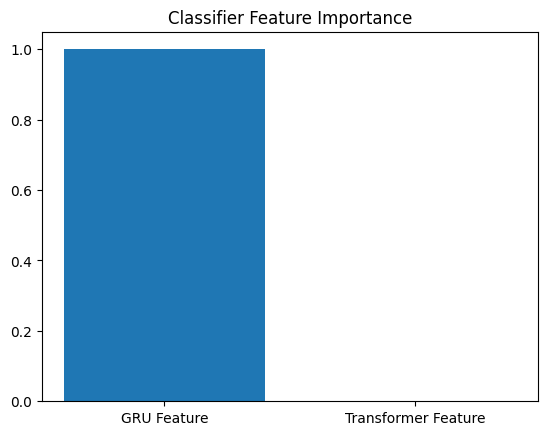

In [ ]:
importances = rf.feature_importances_

plt.bar(["GRU Feature","Transformer Feature"], importances)
plt.title("Classifier Feature Importance")
plt.show()


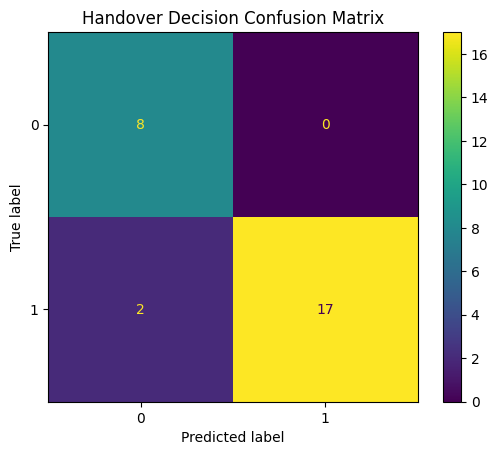

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(rf, X_test, y_test)
plt.title("Handover Decision Confusion Matrix")
plt.show()
